In [11]:
import pandas as pd

import re

# Data Cleaning

I collaborated with ChatGPT and Claude to clean up my edgelist. Since I already crawled the internet, it was able to just use my JSON data rather than crawl a thousand websites. Much faster I got good results this way. I can now use this approach to expand into any location in the world.

In [2]:
data = r'C:\Users\itsgo\PythonCode\verdant_intelligence\exports\gs_signal_edgelist_20260813.csv'

df = pd.read_csv(data)
df.dropna(inplace=True)
df

,domain,page_title,linked_domains
0,tinystartups.com,Tiny Startups — Discover & Launch the Best New...,contextbolt.com
1,music-club.ro,Acasa - Music Club,musicmix.ro
2,mfk-berlin.de,Museum für Kommunikation Berlin – Vergangenhei...,apropos-sex.museumsstiftung.de
3,bbs123.cn,论坛大全 - 创建与管理网络论坛社区,xjart.bbs123.cn
4,bartvanhauwermeiren.be,Elektricien - Warmtepompen - Airco - Zonnepane...,instagram.com
...,...,...,...
195976,latter-blum.com,"Real Estate, Homes for Sale & Apartments for R...",compass-sell.com
195977,pennstatehealthnews.org,Penn State Health News,med.psu.edu
195978,las-raznolikost-podezelja.si,LAS | Raznolikost podeželja – VODILNI PARTNER:...,simbio.si
195979,geektyrant.com,GeekTyrant – Geek Movie and Entertainment News,facebook.com


In [3]:
# I will use this for my filtering and to understand the scale. i am not going to show the results. 
# there are so many adult websites, and that has been true since day one of the internet
# if you do OSINT, you typically want to filter them out
junk_mask = df['page_title'].str.contains('porn|sex|jav|singles|dating|escort|hentai|voyeur|naked|xxx|adult|blocked', case=False)

junk_df = df[junk_mask]
junk_df.shape

(7012, 3)

In [4]:
df = df[~junk_mask].copy() # if you want the opposite of the filter, then you use the ~ mark
df.head()

,domain,page_title,linked_domains
0,tinystartups.com,Tiny Startups — Discover & Launch the Best New...,contextbolt.com
1,music-club.ro,Acasa - Music Club,musicmix.ro
2,mfk-berlin.de,Museum für Kommunikation Berlin – Vergangenhei...,apropos-sex.museumsstiftung.de
3,bbs123.cn,论坛大全 - 创建与管理网络论坛社区,xjart.bbs123.cn
4,bartvanhauwermeiren.be,Elektricien - Warmtepompen - Airco - Zonnepane...,instagram.com


In [5]:
df.shape

(182308, 3)

In [6]:
title_filter = (
    # English
    'live music|concert|concerts|music festival|music festivals|music venue|music hall|'
    'live performance|open mic|jam session|musician|musicians|'
    'rock music|rock band|rock bands|rock festival|rock concert|'
    'jazz|punk|metal|blues|folk|acoustic|nightlife|'
    'performing arts|theatre|theater|orchestra|'
    'opera house|opera festival|opera company|'
    'dj set|dj sets|dj music|dj night|'
    'local music|local artist|local artists|community music|music calendar|concert calendar|'

    # German
    'livemusik|live musik|konzert|konzerte|musikfestival|musikfestivals|'
    'musikclub|musikhalle|konzerthalle|veranstaltungskalender|'
    'musiker|jazz|punk|metal|blues|akustik|'
    'rockmusik|rockband|rockfestival|rockkonzert|'
    'theater|orchester|musikschule|musikverein|innenhofkonzerte|'
    'opernhaus|opernfestival|'

    # French
    'musique live|musique en direct|concert|concerts|festival de musique|'
    'salle de concert|salle de musique|musicien|musiciens|groupe de musique|'
    'jazz|punk|metal|blues|acoustique|'
    'rock musique|groupe de rock|festival rock|concert rock|'
    'spectacle vivant|théâtre|orchestre|'
    'opéra national|festival d’opéra|maison d’opéra|'

    # Spanish
    'música en vivo|musica en vivo|concierto|conciertos|festival de música|festival de musica|'
    'sala de conciertos|sala de música|sala de musica|músico|musico|músicos|musicos|'
    'jazz|punk|metal|blues|acústico|acustico|'
    'música rock|musica rock|banda de rock|festival de rock|concierto de rock|'
    'teatro|orquesta|'
    'teatro de ópera|teatro de opera|festival de ópera|festival de opera|'

    # Italian
    'musica dal vivo|concerto|concerti|festival musicale|festival di musica|'
    'locale di musica|locale musica|sala concerti|musicista|musicisti|'
    'jazz|punk|metal|blues|acustico|'
    'musica rock|rock band|festival rock|concerto rock|'
    'teatro|orchestra|'
    'teatro dell’opera|teatro dell opera|festival lirico|festival opera|'

    # Dutch
    'live muziek|concert|concerten|muziekfestival|muziekfestivals|'
    'muziekpodium|muziekzaal|concertzaal|muzikant|muzikanten|'
    'jazz|punk|metal|blues|akoestisch|'
    'rockmuziek|rockband|rockfestival|rockconcert|'
    'theater|orkest|'
    'operahuis|operafestival|'

    # Swedish
    'livemusik|konsert|konserter|musikfestival|musikfestivaler|'
    'musikscen|konserthus|musiker|'
    'jazz|punk|metal|blues|akustisk|'
    'rockmusik|rockband|rockfestival|rockkonsert|'
    'teater|orkester|'
    'operahus|operafestival|'

    # Polish
    'muzyka na żywo|koncert|koncerty|festiwal muzyczny|festiwale muzyczne|'
    'klub muzyczny|sala koncertowa|muzyk|muzycy|zespół muzyczny|'
    'jazz|punk|metal|blues|akustyczny|'
    'muzyka rockowa|zespół rockowy|festiwal rockowy|koncert rockowy|'
    'teatr|orkiestra|'
    'opera narodowa|festiwal operowy|'

    # Czech
    'živá hudba|ziva hudba|koncert|koncerty|hudební festival|hudebni festival|'
    'hudební klub|hudebni klub|koncertní sál|koncertni sal|hudebník|hudebnici|kapela|'
    'jazz|punk|metal|blues|akustická hudba|'
    'rocková hudba|rockova hudba|rocková kapela|rockovy festival|rockový koncert|'
    'divadlo|orchestr|'
    'operní dům|operni dum|operní festival|operni festival|'

    # Turkish
    'canlı müzik|canli muzik|konser|konserler|müzik festivali|muzik festivali|'
    'müzik mekanı|muzik mekani|konser salonu|müzisyen|muzisyen|'
    'müzik grubu|muzik grubu|açık mikrofon|acik mikrofon|jam session|'
    'yerel müzik|yerel muzik|yerel sanatçı|yerel sanatci|'
    'caz|punk|metal|blues|akustik|'
    'rock müzik|rock muzik|rock grubu|rock festivali|rock konseri|'
    'tiyatro|orkestra|'
    'opera binası|opera binasi|opera festivali|'

    # Japanese
    'ライブハウス|ライブ音楽|生演奏|コンサート|演奏会|音楽祭|'
    '音楽フェス|ライブイベント|コンサートホール|音楽ホール|'
    'ミュージシャン|バンド|歌手|シンガー|'
    'ジャズ|ロック|パンク|メタル|ブルース|アコースティック|'
    'オープンマイク|ジャムセッション|'
    '劇場|演劇|オペラハウス|オペラ公演|オーケストラ'
)

check_df = df[df['page_title'].str.contains(title_filter, case=False, na=False)]
check_df.shape

(2150, 3)

In [7]:
titles = sorted(check_df['page_title'].value_counts().index.values)
titles[0:10]

['- All about concerts & festivals',
 'A.J. Vega - diy furry noise pop musician',
 'ADOK | Digital Thinking. Agenzia di comunicazione a Bergamo.',
 'Accademia Di Comunicazione Corsi E Master In Marketing Art Direction Grafica Copywriting - Fondazione Accademia Di Comunicazione',
 'Advisor Metals - CDM - Human Reporters • Not Machines',
 'Agenzia di Comunicazione Roma | dunp | Web Marketing Adv',
 'Agenzia di comunicazione a Trieste - Publimedia Web Agency',
 'Akaan kaupunki - Aikaa elää',
 'Alfa Matrix Records - Electro - Industrial - Darkwave - Post-Punk',
 'Alice Boyd | Musician, Sound Artist, Audio Producer I Environmental artist']

In [12]:
title_file = r'C:\Users\itsgo\OneDrive\Desktop\keeper_domain_titles.txt'

# doing it this way to keep titles that have columns without screwing up the read_csv
with open(title_file, 'r', encoding='utf-8') as f:
    titles = [line.strip() for line in f if line.strip()]

keep_df = pd.DataFrame({'page_title': titles})

keep_df

,page_title
0,"- Portale di letteratura, arte, musica, costum..."
1,.Michael Bailey-Gates Photography- Michael Bai...
2,"100PercentFedUp.com – Conservative news, socia..."
3,101 Wildlife Crossing – We welcome you in join...
4,24.hu - Friss hírek - hiteles tartalom
...,...
910,Website for jazz trumpeter Thomas Marriott
911,Winnetka Music Festival
912,WojArt poleca najlepsze komedie teatralne po p...
913,"WojArt – teatr, eventy w Poznaniu"


In [13]:
keepers_df = keep_df.merge(df, on='page_title', how='left')
keepers_df.drop_duplicates(inplace=True)
keepers_df.head()

,page_title,domain,linked_domains
0,"- Portale di letteratura, arte, musica, costum...",interzona.news,themeansar.com
1,"- Portale di letteratura, arte, musica, costum...",interzona.news,facebook.com
2,"- Portale di letteratura, arte, musica, costum...",interzona.news,it.wordpress.org
3,"- Portale di letteratura, arte, musica, costum...",interzona.news,interzona.news
4,.Michael Bailey-Gates Photography- Michael Bai...,NaN,NaN


In [14]:
fails_df = keepers_df[keepers_df['domain'].isna()]
failed_titles = fails_df['page_title'].tolist()

pattern = '|'.join(re.escape(title) for title in failed_titles)

fail_capture_df = df[df['page_title'].str.contains(pattern, case=False, na=False)].copy()
fail_capture_df.dropna(inplace=True)
fail_capture_df.drop_duplicates(inplace=True)
fail_capture_df.shape

(113, 3)

In [15]:
final_df = pd.concat([keepers_df, fail_capture_df], ignore_index=True)
final_df.dropna(inplace=True)
final_df.columns = ['page_title', 'domain', 'linked_domain']

final_df['domain'] = final_df['domain'].str.lower()
final_df['linked_domain'] = final_df['linked_domain'].str.lower()

drop_pattern = 'store'

final_df = final_df[
    ~final_df['domain'].str.contains(drop_pattern, na=False) &
    ~final_df['linked_domain'].str.contains(drop_pattern, na=False)
]

junk_domains = (
    'facebook.com|instagram.com|youtube.com|twitter.com|x.com|'
    'tiktok.com|linkedin.com|bsky.app|reddit.com|threads.net|google.com|amazon.com'
)

final_df = final_df[
    ~final_df['domain'].str.contains(junk_domains, na=False) &
    ~final_df['linked_domain'].str.contains(junk_domains, na=False)
]

final_df.drop_duplicates(inplace=True)

final_df.head()

,page_title,domain,linked_domain
0,"- Portale di letteratura, arte, musica, costum...",interzona.news,themeansar.com
2,"- Portale di letteratura, arte, musica, costum...",interzona.news,it.wordpress.org
3,"- Portale di letteratura, arte, musica, costum...",interzona.news,interzona.news
6,"100PercentFedUp.com – Conservative news, socia...",100percentfedup.com,dailynoah.com
7,"100PercentFedUp.com – Conservative news, socia...",100percentfedup.com,gettr.com


In [16]:
data= r'C:\Users\itsgo\OneDrive\Desktop\verdant\websites.csv'

crawl_df = pd.read_csv(data, header=None)
crawl_df.columns = ['domain']
crawl_domains = sorted(set(crawl_df['domain'].values))
len(crawl_domains)

8765

In [17]:
# all domains are keepers
keeper_domains = sorted(set(final_df['domain'].unique()))

keeper_domains = [k for k in keeper_domains if k not in crawl_domains]
print(len(keeper_domains))
#keeper_domains

772


In [18]:
# all linked_domains are candidates for expansion

In [19]:
candidate_domains = (
    final_df['linked_domain']
    .dropna()
    .drop_duplicates()
)

candidate_domains = candidate_domains[
    ~candidate_domains.isin(keeper_domains)
]

candidate_domains = [c for c in sorted(set(candidate_domains)) if c not in crawl_domains]

len(candidate_domains)

5254

In [20]:
# extra domains found in linked_domains

In [21]:
#candidate_domains[5000:6000]

In [22]:
data = r'C:\Users\itsgo\OneDrive\Desktop\candidate_keeper_linked_domains.csv'

candidate_keepers = pd.read_csv(data, header=None)
candidate_keepers.columns = ['domain']
candidate_keeper_domains = sorted(set(candidate_keepers['domain'].values))
candidate_keeper_domains[0:5]

['abc.net.au', 'acllive.com', 'advocate.com', 'aei.org', 'aerospace.org']

In [23]:
final_expansion_domain_set = sorted(set(keeper_domains + candidate_keeper_domains))
len(final_expansion_domain_set)

1845

In [24]:
#[print(d) for d in final_expansion_domain_set]

# Graph Analysis

My goal is to identify several websites that talk about aspects of life in Japan, including but not limited to music, art, and events. Mainly, I want to remove junk and see what is left that may be useful as a source of information. Then I will inspect closer once I have an overall map.

In [148]:
import networkx as nx
import numpy as np
import pandas as pd

# for the explode statement; convert string to list
from ast import literal_eval

# for visualization
from IPython.display import SVG 
from sknetwork.visualization import svg_graph 
from sknetwork.data import Bunch 
from sknetwork.ranking import PageRank 
from scipy.sparse import csr_matrix

def draw_graph(G, show_names=False, node_size=1, font_size=10, edge_width=0.5):

    adjacency = nx.to_scipy_sparse_array(G, nodelist=None, dtype=None, weight='weight', format='csr')
    adjacency = csr_matrix(adjacency) # fix to weird sknetwork-csr issue; comment out to troubleshoot
    
    names = np.array(list(G.nodes))
    
    graph = Bunch()
    graph.adjacency = adjacency
    graph.names = np.array(names)
    
    pagerank = PageRank()
    scores = pagerank.fit_transform(adjacency)

    if show_names:
        
        image = svg_graph(graph.adjacency, font_size=font_size, node_size=node_size, names=graph.names, width=700, height=500, scores=scores, edge_width=edge_width)
    
    else:
        
        image = svg_graph(graph.adjacency, node_size=node_size, width=700, height=500, scores = scores, edge_width=edge_width)
    
    return SVG(image)

In [149]:
G = nx.from_pandas_edgelist(final_df, 'domain', 'linked_domain')
print(G)

Graph with 6356 nodes and 8759 edges


In [150]:
#draw_graph(G, edge_width=0.1, node_size=3)

I originally used my pre-LLM graph methods, but then I had an idea to save a lot of time, so collaborated with AI (Claude and ChatGPT) to filter the edgelist directly rather than crawling hundreds of websites. I already did that for them, which made the collaboration a lot faster.

I am hunting for 1) news, 2) music, 3) art, 4) cultural informaiton, 5) event information, 6) other information families use.

Let's use Page Rank and Egocentric Network Analysis to zoom in with our Graph Microscope. :)

In [151]:
[n for n in sorted(G.nodes) if 'city' in n.lower()] # other city nodes

['aalencityaktiv.de',
 'agri-city.info',
 'augsburg-city.de',
 'bellecityresale.com',
 'bochum-smartcity.de',
 'brasovcity.ro',
 'citybiz.co',
 'citycard.de',
 'cityjsconf.org',
 'citypartner-offenburg.com',
 'citysidejournalism.org',
 'citywinery.com',
 'cmcitymedia.de',
 'geniusvelocity.com',
 'greencity.freiburg.de',
 'hub.cityspark.com',
 'jetcitystar.blogspot.com',
 'login.cityspark.com',
 'miamicityballet.org',
 'nextcity.org',
 'recruiting.paylocity.com',
 'smartcity.ms',
 'smartcity.potsdam.de',
 'smokecity.hu']

In [152]:
# keywords = ['music', 'art', 'community']

# [n for n in sorted(G.nodes) if any(kw in n.lower() for kw in keywords)]

# Page Rank Analysis

Let's see what Page Rank thinks are the most important nodes in the graph.

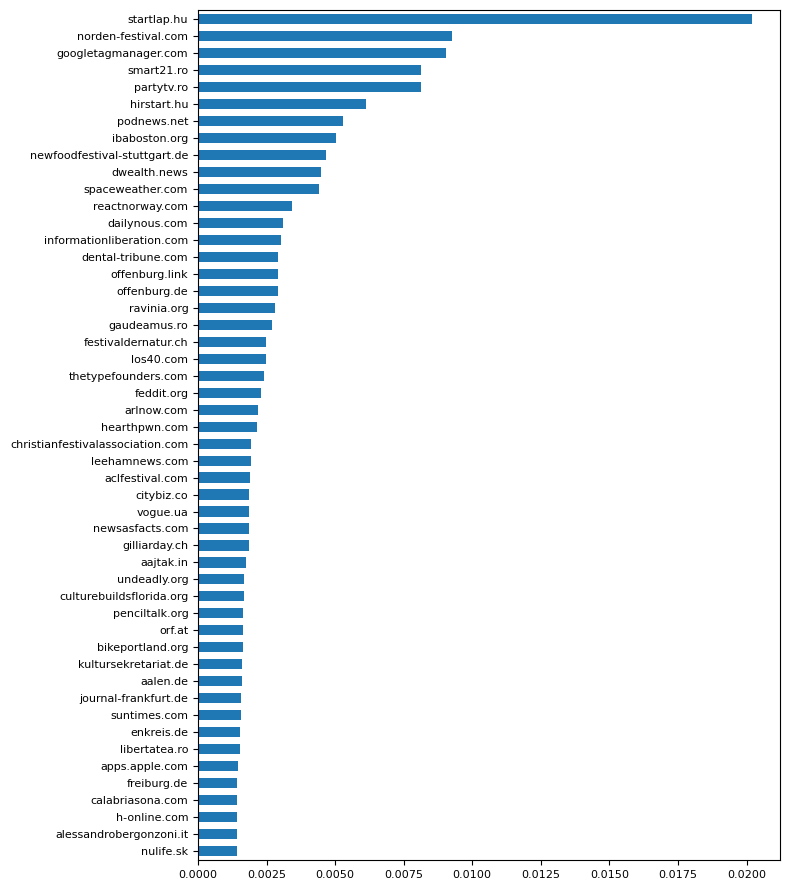

In [153]:
import matplotlib.pyplot as plt

top_domains = pd.Series(nx.pagerank(G)).sort_values(ascending=False)[:50]
top_domains[::-1].plot.barh(figsize=(8, 9), width=0.6, fontsize=8)
plt.tight_layout()

In [57]:
def draw_ego(G, center, radius=1, node_size=4, show_names=True):

    ego = nx.ego_graph(G, center, radius=radius)

    for domain in sorted(ego.nodes):
        print(domain)
        
    return draw_graph(ego, node_size=node_size, show_names=show_names)

In [146]:
# draw_ego(G, top_domains.index[0])